# DMET 1001 — Image Processing Assignment 1
**German University in Cairo** | Dr. Mohamed Karam Gabr | **Due: 14 April 2026**

---
## Cell 1 — Imports

In [44]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import pywt

print('All imports successful')

All imports successful


---
## Cell 2 — Unified Parameters
These values are identical across all 4 domain experiments. Do not change them inside a domain section.

In [45]:
# ── Dataset ───────────────────────────────────────────────────────────────────
# We use 5 out of CIFAR-10's 10 classes — chosen for visual diversity
SELECTED_CLASSES = [0, 1, 2, 8, 9]        # airplane, automobile, bird, ship, truck
CLASS_NAMES      = ['airplane', 'automobile', 'bird', 'ship', 'truck']
NUM_CLASSES      = len(SELECTED_CLASSES)   # 5
DATA_DIR         = 'data'

# ── Split ─────────────────────────────────────────────────────────────────────
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15

# ── Training (must be identical across all 4 experiments) ─────────────────────
BATCH_SIZE    = 64
NUM_EPOCHS    = 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
SEED          = 42

# ── Input sizes ───────────────────────────────────────────────────────────────
CIFAR_SIZE       = 32    # native CIFAR-10 image size
MODEL_INPUT_SIZE = 224   # MobileNet expects 224x224

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Classes     : {CLASS_NAMES}')
print(f'Num classes : {NUM_CLASSES}')
print(f'Device      : {device}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Epochs      : {NUM_EPOCHS}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Optimizer   : Adam')
print(f'Split       : {int(TRAIN_RATIO*100)}/{int(VAL_RATIO*100)}/{int(TEST_RATIO*100)}')
print(f'Seed        : {SEED}')

Classes     : ['airplane', 'automobile', 'bird', 'ship', 'truck']
Num classes : 5
Device      : cpu
Batch size  : 64
Epochs      : 10
Learning rate: 0.0003
Optimizer   : Adam
Split       : 70/15/15
Seed        : 42


---
## Cell 3 — Dataset Loader (shared)

In [46]:
def get_dataloaders(transform_fn):
    """
    Downloads CIFAR-10, filters to SELECTED_CLASSES only, and returns
    train / val / test DataLoaders.
    Labels are remapped to 0-4 so the model always sees 0-indexed classes.
    The split is fixed by SEED so all 4 domains see the exact same images.
    """
    # Download CIFAR-10
    train_data = datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=ToTensor())
    test_data  = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=ToTensor())

    # Map original class index → new 0-based index  e.g. {0:0, 1:1, 2:2, 8:3, 9:4}
    label_map = {orig: new for new, orig in enumerate(SELECTED_CLASSES)}

    def filter_and_remap(dataset):
        indices, new_labels = [], []
        counts = {c: 0 for c in label_map}
        for i, lbl in enumerate(dataset.targets):
            if lbl in label_map and counts[lbl] < 2000:
                indices.append(i)
                new_labels.append(label_map[lbl])
                counts[lbl] += 1
        return indices, new_labels

    train_idx, train_labels = filter_and_remap(train_data)
    test_idx,  test_labels  = filter_and_remap(test_data)

    # 70/15 stratified split on the filtered training set
    rng    = np.random.default_rng(SEED)
    labels = np.array(train_labels)
    split_train_idx, split_val_idx = [], []

    for cls in range(NUM_CLASSES):
        idx = np.where(labels == cls)[0]
        rng.shuffle(idx)
        n = int(len(idx) * TRAIN_RATIO / (TRAIN_RATIO + VAL_RATIO))
        split_train_idx.extend(idx[:n].tolist())
        split_val_idx.extend(idx[n:].tolist())

    class _DS(Dataset):
        def __init__(self, base, indices, labels, fn):
            self.base, self.indices, self.labels, self.fn = base, indices, labels, fn
        def __len__(self): return len(self.indices)
        def __getitem__(self, i):
            img, _ = self.base[self.indices[i]]
            return self.fn(img), self.labels[i]

    train_labels = np.array(train_labels)
    train_ds = _DS(train_data, [train_idx[i] for i in split_train_idx], train_labels[split_train_idx], transform_fn)
    val_ds   = _DS(train_data, [train_idx[i] for i in split_val_idx],   train_labels[split_val_idx],   transform_fn)
    test_ds  = _DS(test_data,  test_idx, np.array(test_labels), transform_fn)

    print(f'train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}')

    kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=False)
    return (DataLoader(train_ds, shuffle=True,  **kw),
            DataLoader(val_ds,   shuffle=False, **kw),
            DataLoader(test_ds,  shuffle=False, **kw))

print('get_dataloaders ready')

get_dataloaders ready


---
## Cell 4 — Model (shared)

In [47]:
def get_model(in_channels=3):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    if in_channels != 3:
        old = model.features[0][0]
        model.features[0][0] = nn.Conv2d(
            in_channels, old.out_channels,
            kernel_size=old.kernel_size, stride=old.stride,
            padding=old.padding, bias=False
        )

    # Add dropout before final layer to reduce overfitting
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    )
    return model

print('get_model ready')

get_model ready


---
## Cell 5 — Training & Evaluation Utilities (shared)

In [48]:
class History:
    """Stores train/val loss and accuracy for every epoch."""
    def __init__(self):
        self.train_loss, self.train_acc = [], []
        self.val_loss,   self.val_acc   = [], []
    def record(self, tl, ta, vl, va):
        self.train_loss.append(tl); self.train_acc.append(ta)
        self.val_loss.append(vl);   self.val_acc.append(va)


def run_epoch(model, loader, criterion, optimizer=None):
    """One training or validation pass. If optimizer is None → eval mode."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            if training: loss.backward(); optimizer.step()
            preds = outputs.argmax(1)
            total_loss += loss.item() * labels.size(0)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss/total, correct/total, np.array(all_preds), np.array(all_labels)


def train_model(domain, transform_fn, in_channels):
    """Full training pipeline for one domain."""
    print(f'\n===== Training: {domain} =====')
    train_loader, val_loader, test_loader = get_dataloaders(transform_fn)

    model     = get_model(in_channels).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history   = History()

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _ = run_epoch(model, val_loader,   criterion)
        history.record(tr_loss, tr_acc, vl_loss, vl_acc)
        print(f'Epoch {epoch:02d} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}')

    # Final test evaluation
    _, test_acc, test_preds, test_labels = run_epoch(model, test_loader, criterion)
    print(f'\n[{domain}] Test Accuracy: {test_acc:.4f}')

    # Save model weights
    os.makedirs('results', exist_ok=True)
    torch.save(model.state_dict(), f'results/{domain}_weights.pth')

    return model, history, test_preds, test_labels


def plot_results(domain, history, test_preds, test_labels):
    """Plots loss curves and confusion matrix for a domain."""
    epochs = range(1, len(history.train_loss) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, history.train_loss, label='Train')
    axes[0].plot(epochs, history.val_loss,   label='Val')
    axes[0].set_title(f'{domain} — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(epochs, history.train_acc, label='Train')
    axes[1].plot(epochs, history.val_acc,   label='Val')
    axes[1].set_title(f'{domain} — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
    axes[2].set_title(f'{domain} — Confusion Matrix')
    axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

    plt.tight_layout()
    plt.show()

print('Training and evaluation utilities ready')

Training and evaluation utilities ready


---
## Domain 1 — Raw Spatial (RGB)
**Subteam A: Habiba, Fareeda**

The baseline. We feed the original RGB image directly into MobileNet after resizing and normalising. No transformation is applied to the image content.

In [ ]:
# --- SPATIAL TRANSFORM ---
# Input:  (3, 32, 32) tensor in [0, 1]
# Output: (3, 224, 224) tensor — resized and normalised with ImageNet mean/std

# Steps:
#   1. Resize from 32x32 to 224x224 using F.interpolate (bilinear)
#   2. Normalise with ImageNet mean=[0.485,0.456,0.406] and std=[0.229,0.224,0.225]

def spatial_transform(image):
    pass  # replace with your code

In [ ]:
# --- VISUALISE A FEW SPATIAL IMAGES ---
# Show 6 sample images after the spatial transform
# Use plt.imshow — remember to clamp values to [0,1] and permute to (H,W,C)


In [ ]:
# --- TRAIN SPATIAL ---
spatial_model, spatial_history, spatial_preds, spatial_labels = train_model(
    domain       = 'spatial',
    transform_fn = spatial_transform,
    in_channels  = 3
)

In [ ]:
# --- RESULTS ---
plot_results('spatial', spatial_history, spatial_preds, spatial_labels)

---
## Domain 2 — Fourier Domain
**Subteam A: Habiba, Fareeda**

**What the frequency domain represents:**  
*Every image can be expressed as a sum of sinusoidal waves of varying frequency, amplitude, and orientation. The 2D Fourier transform converts a spatial image (pixel intensities at x,y positions) into this frequency representation. After applying fftshift, the centre of the resulting spectrum holds the low-frequency components — gradual changes in brightness and colour across the image, corresponding to the overall shape of objects. The outer regions of the spectrum hold the high-frequency components, which encode sharp edges, fine texture, and fine detail. Taking the log-magnitude compresses the spectrum's wide dynamic range into values a neural network can learn from.*

**Why it may help classification:**  
*Different object classes tend to produce characteristic frequency signatures. Organic objects like birds have rich high-frequency energy from feather texture and irregular edges, while man-made vehicles like automobiles and ships tend to have energy concentrated in lower frequencies due to their smoother, more geometric surfaces. Crucially, the magnitude spectrum is also largely shift-invariant — an airplane in the top-left corner of a frame produces nearly the same spectrum as one centred in the frame. This means the Fourier domain may help the classifier focus on what an object looks like rather than where it appears, which is a useful property for a CNN that will encounter objects at various positions.*

In [49]:
def fourier_transform(image):
    # image: (3, 32, 32) tensor in [0, 1]
    channels = []
    for c in range(3):
        channel = image[c]                              # (32, 32)
        fft     = torch.fft.fft2(channel)              # 2D FFT
        fft     = torch.fft.fftshift(fft)              # zero-freq to centre
        mag     = torch.abs(fft)                       # magnitude
        log_mag = torch.log1p(mag)                     # log(1 + x)
        # normalise to [0, 1]
        log_mag = (log_mag - log_mag.min()) / (log_mag.max() - log_mag.min() + 1e-8)
        channels.append(log_mag)

    result = torch.stack(channels, dim=0)              # (3, 32, 32)
    # resize to 224x224
    result = F.interpolate(
        result.unsqueeze(0),                           # (1, 3, 32, 32)
        size=(224, 224),
        mode='bilinear',
        align_corners=False
    ).squeeze(0)                                       # (3, 224, 224)
    return result

c:\Users\Habiba Elguindy\imga1\image-processing-a1\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


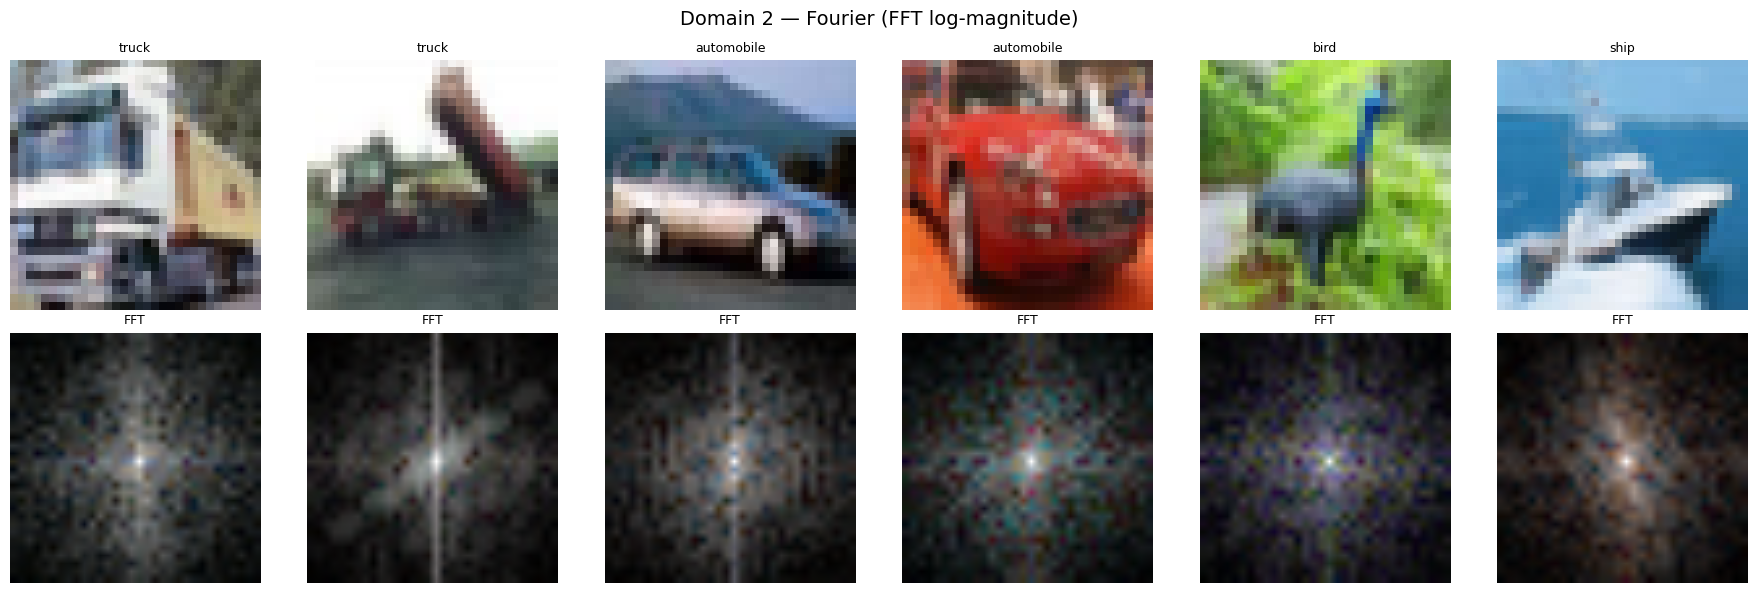

Fourier sample visualisation saved.


In [50]:
# --- VISUALISE FFT LOG-MAGNITUDE ---
# Load a small batch from CIFAR-10 to grab sample images
raw_data = datasets.CIFAR10(root=DATA_DIR, train=True, download=False, transform=ToTensor())
label_map = {orig: new for new, orig in enumerate(SELECTED_CLASSES)}

# Collect 6 samples (one per class would be ideal, but just grab the first 6 from selected classes)
samples = []
for img, lbl in raw_data:
    if lbl in label_map and len(samples) < 6:
        samples.append((img, CLASS_NAMES[label_map[lbl]]))
    if len(samples) == 6:
        break

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Domain 2 — Fourier (FFT log-magnitude)', fontsize=14)

for i, (img, name) in enumerate(samples):
    # Top row: original RGB
    orig = img.permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig)
    axes[0, i].set_title(name, fontsize=9)
    axes[0, i].axis('off')

    # Bottom row: FFT log-magnitude (show green channel for clarity)
    fft_img = fourier_transform(img)          # (3, 224, 224)
    fft_display = fft_img.permute(1, 2, 0).numpy()
    axes[1, i].imshow(fft_display)
    axes[1, i].set_title('FFT', fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('FFT log-mag', fontsize=10)

plt.tight_layout()
plt.savefig('results/fourier_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fourier sample visualisation saved.')

In [51]:
# --- TRAIN FOURIER ---
fourier_model, fourier_history, fourier_preds, fourier_labels = train_model(
    domain       = 'fourier',
    transform_fn = fourier_transform,
    in_channels  = 3
    
)


===== Training: fourier =====
train: 8235 | val: 1765 | test: 5000
Epoch 01 | train_loss=1.1530 train_acc=0.5150 | val_loss=0.9612 val_acc=0.6159
Epoch 02 | train_loss=0.8687 train_acc=0.6635 | val_loss=0.9807 val_acc=0.6193
Epoch 03 | train_loss=0.6670 train_acc=0.7403 | val_loss=0.9429 val_acc=0.6436
Epoch 04 | train_loss=0.4802 train_acc=0.8186 | val_loss=1.1135 val_acc=0.6142
Epoch 05 | train_loss=0.3038 train_acc=0.8855 | val_loss=1.4387 val_acc=0.5977
Epoch 06 | train_loss=0.1985 train_acc=0.9294 | val_loss=1.6400 val_acc=0.5756
Epoch 07 | train_loss=0.1666 train_acc=0.9412 | val_loss=1.5598 val_acc=0.6096
Epoch 08 | train_loss=0.0931 train_acc=0.9705 | val_loss=1.6629 val_acc=0.6006
Epoch 09 | train_loss=0.0765 train_acc=0.9738 | val_loss=1.8247 val_acc=0.6210
Epoch 10 | train_loss=0.0937 train_acc=0.9668 | val_loss=1.7110 val_acc=0.6130

[fourier] Test Accuracy: 0.6038


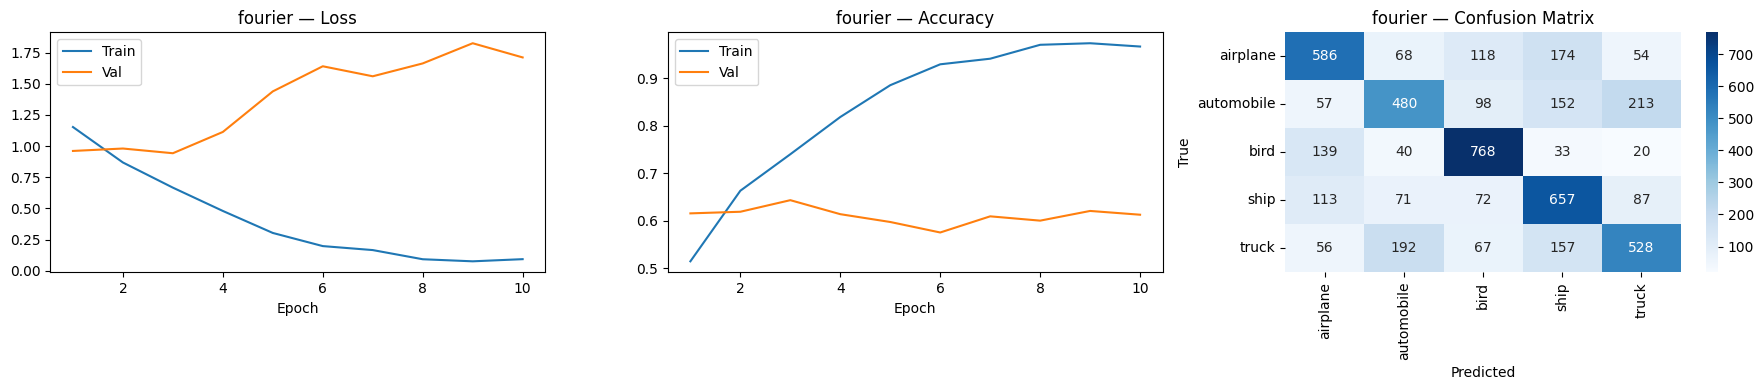


Per-class accuracy — Fourier domain:
  airplane     0.5860
  automobile   0.4800
  bird         0.7680
  ship         0.6570
  truck        0.5280


In [52]:
# --- RESULTS ---
plot_results('fourier', fourier_history, fourier_preds, fourier_labels)

# Extra: per-class accuracy breakdown
print('\nPer-class accuracy — Fourier domain:')
for i, cls in enumerate(CLASS_NAMES):
    mask     = fourier_labels == i
    cls_acc  = (fourier_preds[mask] == fourier_labels[mask]).mean()
    print(f'  {cls:<12} {cls_acc:.4f}')

---
## Domain 3 — Wavelet Domain
**Subteam B: Nour, Haya**

**Wavelet choice and justification:**
*We used the Haar wavelet for the Discrete Wavelet Transform (DWT). Haar was chosen because it is simple, fast, and works well for small images such as CIFAR-10. It separates the image into low-frequency and high-frequency components, which helps represent both the overall shape and the fine details of the image.*

**Subband selection (LL only or all 4) and why:**
*We used all 4 subbands: LL, LH, HL, and HH. The LL subband keeps the main structure and smooth information of the image, while LH, HL, and HH keep edge and texture details in different directions. Using all four subbands gives the model more information than using LL only, which may improve classification performance.*

In [53]:
# --- WAVELET TRANSFORM ---
# Input:  (3, 32, 32) tensor in [0, 1]
# Output: (12, 224, 224) tensor — 4 subbands x 3 channels, resized

def wavelet_transform(image):
    image_np = image.numpy()
    parts = []
    for c in range(3):
        channel = image_np[c]
        LL, (LH, HL, HH) = pywt.dwt2(channel, 'haar')
        for band in [LL, LH, HL, HH]:
            band = band.astype(np.float32)
            mn, mx = band.min(), band.max()
            if mx > mn:
                band = (band - mn) / (mx - mn)
            else:
                band = np.zeros_like(band, dtype=np.float32)
            parts.append(torch.tensor(band, dtype=torch.float32))
    x = torch.stack(parts)                    # (12, 16, 16)
    x = F.interpolate(
        x.unsqueeze(0),
        size=(224, 224),
        mode='bilinear',
        align_corners=False
    ).squeeze(0)                              # (12, 224, 224)
    return x

In [54]:
x = torch.rand(3, 32, 32)
y = wavelet_transform(x)
print(y.shape)   # should print torch.Size([12, 224, 224])

torch.Size([12, 224, 224])


c:\Users\Habiba Elguindy\imga1\image-processing-a1\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


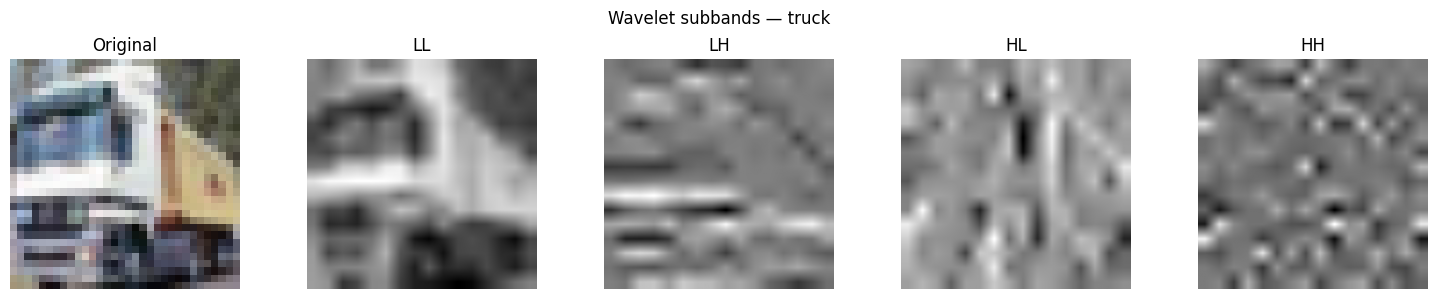

In [55]:
# --- VISUALISE THE 4 SUBBANDS ---
raw_data = datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=ToTensor()
)
for img, lbl in raw_data:
    if lbl in SELECTED_CLASSES:
        original_img   = img
        original_label = lbl
        break

wave_img   = wavelet_transform(original_img)
LL = wave_img[0].cpu().numpy()
LH = wave_img[1].cpu().numpy()
HL = wave_img[2].cpu().numpy()
HH = wave_img[3].cpu().numpy()
orig       = original_img.permute(1, 2, 0).cpu().numpy()
class_name = CLASS_NAMES[SELECTED_CLASSES.index(original_label)]

plt.figure(figsize=(15, 3))
plt.subplot(1, 5, 1); plt.imshow(orig);          plt.title('Original'); plt.axis('off')
plt.subplot(1, 5, 2); plt.imshow(LL, cmap='gray'); plt.title('LL');      plt.axis('off')
plt.subplot(1, 5, 3); plt.imshow(LH, cmap='gray'); plt.title('LH');      plt.axis('off')
plt.subplot(1, 5, 4); plt.imshow(HL, cmap='gray'); plt.title('HL');      plt.axis('off')
plt.subplot(1, 5, 5); plt.imshow(HH, cmap='gray'); plt.title('HH');      plt.axis('off')
plt.suptitle(f'Wavelet subbands — {class_name}')
plt.tight_layout()
plt.show()

In [ ]:
# --- TRAIN WAVELET ---
wavelet_model, wavelet_history, wavelet_preds, wavelet_labels = train_model(
    domain       = 'wavelet',
    transform_fn = wavelet_transform,
    in_channels  = 12   # 4 subbands x 3 channels
)

In [57]:
# --- RESULTS ---
plot_results('wavelet', wavelet_history, wavelet_preds, wavelet_labels)

print('\nPer-class accuracy — Wavelet domain:')
for i, cls in enumerate(CLASS_NAMES):
    mask    = wavelet_labels == i
    cls_acc = (wavelet_preds[mask] == wavelet_labels[mask]).mean()
    print(f'  {cls:<12} {cls_acc:.4f}')

NameError: name 'wavelet_history' is not defined

---
## Domain 4 — Custom Domain
**Subteam B: Nour, Haya**

**Chosen domain:**  
*(write here)*

**Justification — what does this domain capture and why is it useful:**  
*(write here)*

In [ ]:
# --- CUSTOM TRANSFORM ---
# Input:  (3, 32, 32) tensor in [0, 1]
# Output: (C, 224, 224) tensor
# Write your steps as comments before implementing

def custom_transform(image):
    pass  # replace with your code

In [ ]:
# --- VISUALISE CUSTOM TRANSFORMED IMAGES ---


In [ ]:
# --- TRAIN CUSTOM ---
# Change in_channels to match your transform output
custom_model, custom_history, custom_preds, custom_labels = train_model(
    domain       = 'custom',
    transform_fn = custom_transform,
    in_channels  = 3   # change if your transform outputs more channels
)

In [ ]:
# --- RESULTS ---
plot_results('custom', custom_history, custom_preds, custom_labels)

---
## Final Comparison — All 4 Domains

In [ ]:
# --- ACCURACY SUMMARY TABLE ---
results = {
    'spatial': (spatial_history, spatial_preds, spatial_labels),
    'fourier': (fourier_history, fourier_preds, fourier_labels),
    'wavelet': (wavelet_history, wavelet_preds, wavelet_labels),
    'custom':  (custom_history,  custom_preds,  custom_labels),
}

print(f'{"Domain":<10} {"Best Val Acc":>14} {"Test Acc":>10}')
print('-' * 36)
for domain, (hist, preds, labels) in results.items():
    test_acc = (preds == labels).mean()
    print(f'{domain:<10} {max(hist.val_acc):>14.4f} {test_acc:>10.4f}')

In [ ]:
# --- VALIDATION ACCURACY COMPARISON PLOT ---
plt.figure(figsize=(10, 5))
for domain, (hist, _, _) in results.items():
    plt.plot(range(1, NUM_EPOCHS+1), hist.val_acc, label=domain)
plt.title('Validation Accuracy — All Domains')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()